# Position Risk: Crypto Perpetual Futures

Do position-level stops or time exits improve the frozen risk-parity carrier after correcting its
long-short book and settling official funding? This notebook quarantines five historical rules
calibrated on validation, replaces them with pre-validation thresholds, and compares the eligible
read-only surface with the no-overlay allocation baseline.

**Learning objectives**

- Distinguish position-level rules from portfolio-level regime controls
- Compare Sharpe and drawdown on the same funding-inclusive equity definition
- Distinguish fixed rules from thresholds that require ex-ante calibration
- Interpret an overlay winner as validation evidence, not holdout rescue

**Book reference**: Chapter 19, Risk Management

**Prerequisites**: [`14_portfolio_management`](14_portfolio_management.ipynb),
[`15_costs`](15_costs.ipynb), and the frozen `run_log/registry.db`

In [1]:
"""Read-only position-risk replay with official funding settlement."""

import hashlib
import json
import sqlite3
import warnings
from collections import defaultdict
from copy import deepcopy
from datetime import UTC, datetime, timedelta

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.crypto_perps_funding.funding_data import load_funding_rates
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import build_backtest_spec
from case_studies.utils.backtest_runner import precompute_weights, run_backtest
from case_studies.utils.cv_window import canonical_window
from case_studies.utils.registry import read_predictions
from case_studies.utils.sweep_config import calibrate_trailing_stops
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
CASE_STUDY = "crypto_perps_funding"
LABEL = "fwd_ret_24h"
SEED = 42
BAR_HOURS = 8
MAX_SYMBOLS = 0
EXPECTED_REGISTERED_RISK_CELLS = 19
EXPECTED_REPLAY_RISK_CELLS = 20
MAX_RISK_VARIANTS = 0

In [3]:
set_global_seeds(SEED)
FROZEN_CASE_DIR = get_case_study_dir(CASE_STUDY, create=False)
REGISTRY_PATH = FROZEN_CASE_DIR / "run_log" / "registry.db"
config = get_backtest_config(CASE_STUDY)
print(f"Registry: {REGISTRY_PATH.name} (read-only analysis)")

Registry: registry.db (read-only analysis)


~/ml4t/public-release-candidate/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Freeze the allocation carrier and risk grid

The allocation cohort fixes the GBM prediction and risk-parity allocator before overlay analysis.
The registry contributes 19 historical specifications. Five `trailing_mae_*` thresholds were fit
on validation and are audit-only; their replacements use prices strictly before validation.

In [4]:
def _allocation_carrier(registry_path) -> dict:
    """Load the frozen allocation leader for the selected label."""
    query = """
        SELECT b.prediction_hash, b.backtest_hash, b.spec_json,
               m.sharpe, m.max_drawdown
        FROM cohort_metrics c
        JOIN backtest_runs b ON b.backtest_hash = c.leader_hash
        JOIN backtest_metrics m USING (backtest_hash)
        WHERE c.cohort_type = 'stagelabel'
          AND c.stage = 'allocation' AND c.label = ?
    """
    with sqlite3.connect(f"file:{registry_path}?mode=ro", uri=True) as connection:
        row = connection.execute(query, (LABEL,)).fetchone()
    if row is None:
        raise RuntimeError("No frozen allocation leader for the selected label")
    prediction_hash, backtest_hash, spec_json, sharpe, max_drawdown = row
    return {
        "prediction_hash": prediction_hash,
        "backtest_hash": backtest_hash,
        "spec": json.loads(spec_json),
        "stored_sharpe": sharpe,
        "stored_max_drawdown": max_drawdown,
    }

In [5]:
def _validate_carrier(carrier: dict, expected_strategy: dict) -> None:
    """Reject any substitute for the frozen signed allocation carrier."""
    if (
        carrier["prediction_hash"] != "fb85a7d19ce1"
        or carrier["backtest_hash"] != "7d0eb0c542fa"
        or carrier["spec"]["strategy"] != expected_strategy
    ):
        raise RuntimeError("The frozen allocation carrier changed; review the risk narrative")

In [6]:
def _risk_cells(registry_path, prediction_hash: str, expected_strategy: dict) -> list[dict]:
    """Return one registered row per semantic position-risk rule."""
    query = """
        SELECT b.backtest_hash, b.spec_json, m.sharpe, m.max_drawdown
        FROM backtest_runs b JOIN backtest_metrics m USING (backtest_hash)
        WHERE b.stage = 'risk_overlay' AND b.prediction_hash = ?
    """
    with sqlite3.connect(f"file:{registry_path}?mode=ro", uri=True) as connection:
        rows = connection.execute(query, (prediction_hash,)).fetchall()
    cells = {}
    for backtest_hash, spec_json, sharpe, max_drawdown in rows:
        row_strategy = json.loads(spec_json)["strategy"]
        risk = row_strategy.pop("risk")
        if row_strategy != expected_strategy:
            raise RuntimeError(f"Risk row {backtest_hash} does not use the frozen carrier")
        key = json.dumps(risk, sort_keys=True)
        if key in cells:
            raise RuntimeError(f"Duplicate registered risk rule: {risk['name']}")
        cells[key] = {
            "backtest_hash": backtest_hash,
            "risk": risk,
            "stored_sharpe": sharpe,
            "stored_max_drawdown": max_drawdown,
        }
    return [cells[key] for key in sorted(cells)]

In [7]:
def _validate_risk_cells(cells: list[dict], expected_cells: int, reduced_grid: bool) -> None:
    """Reject incomplete, duplicated, or shifted production risk grids."""
    if len(cells) != expected_cells:
        raise RuntimeError(f"Expected {expected_cells} semantic risk rules, found {len(cells)}")
    if reduced_grid:
        return
    risk_keys = sorted(
        json.dumps(cell["risk"], sort_keys=True, separators=(",", ":")) for cell in cells
    )
    risk_digest = hashlib.sha256("|".join(risk_keys).encode()).hexdigest()
    if risk_digest != "a69cfd6fb31958dc6976c77f2fbf7b2276c61c2f27a3585deaa60dcfc6ef1358":
        raise RuntimeError("The registered risk rules differ from the frozen 19-cell surface")

In [8]:
carrier = _allocation_carrier(REGISTRY_PATH)
strategy = carrier["spec"]["strategy"]
signal = strategy["signal"]
allocation = strategy["allocation"]
expected_strategy = {
    "signal": {"long_short": True, "method": "equal_weight_top_k", "top_k": 5},
    "allocation": {
        "long_short": True,
        "method": "risk_parity",
        "top_k": 5,
        "vol_window": 240,
    },
    "rebalance": {
        "cadence": "8_hour_funding_aligned",
        "min_trade_value": 100.0,
        "min_weight_change": 0.005,
        "mode": "engine",
    },
}
_validate_carrier(carrier, expected_strategy)
registered_risk_cells = _risk_cells(REGISTRY_PATH, carrier["prediction_hash"], strategy)
using_reduced_grid = MAX_RISK_VARIANTS > 0
using_fallback_grid = using_reduced_grid and not registered_risk_cells
if not using_fallback_grid:
    _validate_risk_cells(
        registered_risk_cells,
        EXPECTED_REGISTERED_RISK_CELLS,
        reduced_grid=False,
    )
print(
    f"Carrier: prediction={carrier['prediction_hash']} allocation={allocation['method']} "
    f"requested_top_k={allocation['top_k']}; registered risk rules={len(registered_risk_cells)}"
)

Carrier: prediction=fb85a7d19ce1 allocation=risk_parity requested_top_k=5; registered risk rules=19


Production requires the exact historical registry surface before it separates fixed rules from
invalid same-window calibration. Isolated execution can inject three canonical fixed rules.

In [9]:
if using_fallback_grid:
    fallback_risks = [
        {"name": "time_exit_20", "position_rules": [{"bars": 20, "type": "time_exit"}]},
        {
            "name": "trailing_10pct",
            "position_rules": [{"threshold": 0.10, "type": "trailing_stop"}],
        },
        {
            "name": "stop_loss_10pct",
            "position_rules": [{"threshold": 0.10, "type": "stop_loss"}],
        },
    ][:MAX_RISK_VARIANTS]
    risk_cells = [
        {
            "backtest_hash": "",
            "risk": risk,
            "stored_sharpe": float("nan"),
            "stored_max_drawdown": float("nan"),
            "registered_reference": False,
        }
        for risk in fallback_risks
    ]
else:
    fixed_registered = [
        {**cell, "registered_reference": True}
        for cell in registered_risk_cells
        if not cell["risk"]["name"].startswith("trailing_mae_")
    ]
    historical_mae = [
        cell for cell in registered_risk_cells if cell["risk"]["name"].startswith("trailing_mae_")
    ]
    if len(fixed_registered) != 14 or len(historical_mae) != 5:
        raise RuntimeError("Expected 14 fixed and five validation-calibrated historical rules")
    risk_cells = fixed_registered[:MAX_RISK_VARIANTS] if using_reduced_grid else fixed_registered

## Align the frozen artifact and official settlements

Predictions and prices advance together from the legacy bar-open clock to the completed 8-hour
bar. The corrected selector caps each long and short side at half the available cross-section.

In [10]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="'Y' is deprecated", category=FutureWarning)
    validation_window = canonical_window(CASE_STUDY, LABEL, split="validation")
if validation_window is None:
    raise RuntimeError("No canonical validation window")
validation_start, validation_end = validation_window

## Calibrate learned thresholds before validation

The historical `trailing_mae_*` rows are not eligible: their thresholds were calibrated on the
validation prices later used to compare rules. Replacement thresholds use the complete price
prefix ending before the first validation date. Fixed stop-loss, trailing-stop, and time-exit
rules remain exact registered references.

In [11]:
def _prevalidation_mae_cells(validation_start) -> tuple[list[dict], pl.DataFrame]:
    """Calibrate MAE thresholds on prices strictly before validation."""
    calibration_end = validation_start - timedelta(days=1)
    calibration_prices = load_backtest_prices(
        CASE_STUDY,
        max_symbols=MAX_SYMBOLS,
        end_date=calibration_end.isoformat(),
    )
    if calibration_prices.is_empty():
        raise RuntimeError("No pre-validation prices available for MAE calibration")
    if calibration_prices["timestamp"].max().date() >= validation_start:
        raise RuntimeError("MAE calibration admitted validation prices")
    controls = calibrate_trailing_stops(calibration_prices)
    controls_digest = hashlib.sha256(
        json.dumps(controls, sort_keys=True, separators=(",", ":")).encode()
    ).hexdigest()
    if controls_digest != "34219016a0c1f3d669f0295a40cf97f051850eb4c22394c7cda38fa4ab9ab80e":
        raise RuntimeError("Pre-validation MAE calibration surface changed")
    cells = [
        {
            "backtest_hash": "",
            "risk": {
                "name": control["name"],
                "position_rules": [{"threshold": control["threshold"], "type": control["type"]}],
            },
            "stored_sharpe": float("nan"),
            "stored_max_drawdown": float("nan"),
            "registered_reference": False,
            "calibration": control["calibration"],
        }
        for control in controls
    ]
    return cells, calibration_prices

In [12]:
if not using_reduced_grid:
    calibrated_cells, calibration_prices = _prevalidation_mae_cells(validation_start)
    risk_cells += calibrated_cells
    print(
        f"Quarantined {len(historical_mae)} validation-calibrated registry rows; "
        f"fit {len(calibrated_cells)} replacements on "
        f"{calibration_prices['timestamp'].min()} to {calibration_prices['timestamp'].max()}"
    )
    print(
        pl.DataFrame(
            [
                {
                    "historical_rule": cell["risk"]["name"],
                    "historical_threshold": cell["risk"]["position_rules"][0]["threshold"],
                    "eligible": False,
                }
                for cell in historical_mae
            ]
        )
    )
if using_reduced_grid:
    # EXPECTED_REPLAY_RISK_CELLS is the full production count (14 fixed rules plus one
    # recalibrated MAE replacement). MAX_RISK_VARIANTS truncates risk_cells before this
    # point specifically to skip that recalibration, so the reduced count is never 20 by
    # design - only a sanity check applies here, not the production identity pin.
    if not risk_cells:
        raise RuntimeError("Reduced risk grid produced no eligible rules")
elif len(risk_cells) != EXPECTED_REPLAY_RISK_CELLS:
    raise RuntimeError(
        f"Expected {EXPECTED_REPLAY_RISK_CELLS} eligible risk rules, found {len(risk_cells)}"
    )
print(f"Eligible risk rules replayed: {len(risk_cells)}")

Quarantined 5 validation-calibrated registry rows; fit 6 replacements on 2020-01-01 00:00:00 to 2022-01-02 16:00:00
shape: (5, 3)
┌──────────────────────────────┬──────────────────────┬──────────┐
│ historical_rule              ┆ historical_threshold ┆ eligible │
│ ---                          ┆ ---                  ┆ ---      │
│ str                          ┆ f64                  ┆ bool     │
╞══════════════════════════════╪══════════════════════╪══════════╡
│ trailing_mae_p10_h10_11p2pct ┆ 0.112                ┆ false    │
│ trailing_mae_p10_h20_16p1pct ┆ 0.161                ┆ false    │
│ trailing_mae_p10_h40_22p7pct ┆ 0.227                ┆ false    │
│ trailing_mae_p25_h10_6p9pct  ┆ 0.069                ┆ false    │
│ trailing_mae_p25_h20_10p2pct ┆ 0.102                ┆ false    │
└──────────────────────────────┴──────────────────────┴──────────┘
Eligible risk rules replayed: 20


In [13]:
frozen_predictions = read_predictions(
    CASE_STUDY, carrier["prediction_hash"], case_dir=FROZEN_CASE_DIR
)
raw_prices = load_backtest_prices_for(
    CASE_STUDY,
    LABEL,
    split="validation",
    max_symbols=MAX_SYMBOLS,
    warmup_periods=warmup_periods_for(CASE_STUDY),
)
legacy_targets = (
    raw_prices.sort("symbol", "timestamp")
    .with_columns(
        pl.col("close").shift(-3).over("symbol").alias("end_close"),
        pl.col("timestamp").shift(-3).over("symbol").alias("end_timestamp"),
    )
    .filter(pl.col("end_timestamp") == pl.col("timestamp") + pl.duration(hours=24))
    .select(
        pl.col("timestamp").dt.replace_time_zone("UTC"),
        "symbol",
        (pl.col("end_close") / pl.col("close") - 1).alias("current_raw_target"),
    )
)
alignment = frozen_predictions.join(legacy_targets, on=["timestamp", "symbol"], how="inner")
target_correlation = alignment.select(pl.corr("y_true", "current_raw_target")).item()
if target_correlation < 0.99:
    raise ValueError("Frozen prediction timestamps do not match the legacy raw-price clock")
print(f"Frozen target/current raw-price correlation: {target_correlation:.6f}")

Frozen target/current raw-price correlation: 0.999451


In [14]:
predictions = frozen_predictions.with_columns(
    pl.col("timestamp") + pl.duration(hours=BAR_HOURS)
).filter(pl.col("timestamp").dt.date() <= validation_end)
prices = raw_prices.with_columns(pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).filter(
    pl.col("timestamp").dt.date() <= validation_end
)
funding = (
    load_funding_rates(symbols=prices["symbol"].unique().to_list())
    .with_columns(pl.col("timestamp").cast(prices.schema["timestamp"]))
    .filter(
        (pl.col("timestamp") >= prices["timestamp"].min())
        & (pl.col("timestamp") <= prices["timestamp"].max())
    )
)
panel_sizes = predictions.group_by("timestamp").len().rename({"len": "n_assets"})
capped_timestamps = panel_sizes.filter(pl.col("n_assets") < 2 * allocation["top_k"]).height
print(
    f"Predictions: {predictions.height:,}; prices: {prices.height:,}; "
    f"settlements: {funding.height:,}; dynamically capped timestamps: {capped_timestamps}"
)

Predictions: 31,767; prices: 42,198; settlements: 42,338; dynamically capped timestamps: 186


## Funding and equity oracle

Funding is settled on the position carried into each event, before same-time fills. Off-grid
settlements use the last observed mark. Removing cumulative funding from the reconstructed ledger
must reproduce engine equity within floating-point noise.

In [15]:
def _as_utc(value: datetime) -> datetime:
    """Normalize engine timestamps to timezone-aware UTC."""
    return value.replace(tzinfo=UTC) if value.tzinfo is None else value.astimezone(UTC)

In [16]:
def _replay_inputs(result):
    """Index fills, settlements, prices, and engine equity by UTC timestamp."""
    engine = result.engine_result
    if engine is None:
        raise RuntimeError("Funding replay requires an uncached engine result")
    fills = defaultdict(list)
    for fill in engine.fills:
        fills[_as_utc(fill.timestamp)].append(fill)
    rates = defaultdict(dict)
    for row in funding.iter_rows(named=True):
        rates[_as_utc(row["timestamp"])][row["symbol"]] = float(row["funding_rate"])
    marks = defaultdict(dict)
    for row in prices.select("timestamp", "symbol", "close").iter_rows(named=True):
        marks[_as_utc(row["timestamp"])][row["symbol"]] = float(row["close"])
    equity = {_as_utc(ts): float(value) for ts, value in engine.equity_curve}
    return fills, rates, marks, equity

In [17]:
def _replay_equity(result):
    """Return funding-adjusted equity and ledger diagnostics."""
    fills, rates, marks, engine_equity = _replay_inputs(result)
    cash = float(config.initial_cash)
    positions = defaultdict(float)
    funding_pnl = 0.0
    settlements = 0
    adjusted = []
    reconstructed = []
    last_marks = {}
    for timestamp in sorted(set(engine_equity) | set(rates)):
        last_marks.update(marks[timestamp])
        for symbol, rate in rates.get(timestamp, {}).items():
            settlements += 1
            if positions.get(symbol, 0.0) != 0 and symbol in last_marks:
                event_cash = -(positions[symbol] * last_marks[symbol]) * rate
                cash += event_cash
                funding_pnl += event_cash
        for fill in fills.get(timestamp, []):
            quantity = float(fill.quantity) if fill.side.value == "buy" else -float(fill.quantity)
            cash -= quantity * float(fill.price) + float(fill.commission)
            last_marks.setdefault(fill.asset, float(fill.price))
            positions[fill.asset] += quantity
            if abs(positions[fill.asset]) < 1e-12:
                del positions[fill.asset]
        if timestamp in engine_equity:
            marked = sum(quantity * last_marks[symbol] for symbol, quantity in positions.items())
            adjusted.append((timestamp, cash + marked))
            reconstructed.append((timestamp, cash - funding_pnl + marked))
    error = max(abs(value - engine_equity[ts]) for ts, value in reconstructed)
    return adjusted, funding_pnl, settlements, error

In [18]:
def _daily_metrics(equity_curve: list[tuple[datetime, float]]) -> tuple[float, float]:
    """Compute validation Sharpe and maximum drawdown from daily equity."""
    daily = (
        pl.DataFrame(equity_curve, schema=["timestamp", "equity"], orient="row")
        .with_columns(pl.col("timestamp").dt.date().alias("date"))
        .group_by("date")
        .agg(pl.col("equity").sort_by("timestamp").last())
        .sort("date")
        .with_columns(pl.col("equity").pct_change().alias("return"))
        .filter((pl.col("date") >= validation_start) & (pl.col("date") <= validation_end))
    )
    values = daily["equity"].to_numpy()
    returns = daily["return"].drop_nulls().to_numpy()
    sharpe = float(returns.mean() / returns.std(ddof=1) * np.sqrt(365))
    drawdown = values / np.maximum.accumulate(values) - 1
    return sharpe, float(drawdown.min())

## Replay the baseline and 20 eligible position rules

Allocation weights are computed once. Fourteen fixed rules retain their exact registered
dictionaries; six MAE rules use pre-validation calibration. Every run uses `register=False`.

In [19]:
base_spec = build_backtest_spec(
    CASE_STUDY,
    config,
    prices=prices,
    prediction_hash=carrier["prediction_hash"],
    initial_cash=config.initial_cash,
    chapter="ch19",
    signal=signal,
    allocation=allocation,
)
if base_spec["strategy"] != expected_strategy:
    raise RuntimeError("The reconstructed runtime strategy differs from the frozen carrier")
weights = precompute_weights(
    predictions,
    base_spec,
    prices,
    label=LABEL,
    case_study=CASE_STUDY,
    prediction_hash=carrier["prediction_hash"],
).sort("timestamp", "symbol")

In [20]:
def _run_cell(risk: dict | None) -> dict:
    """Run one position-risk cell and add official funding."""
    spec = deepcopy(base_spec)
    if risk is not None:
        spec["strategy"]["risk"] = risk
    result = run_backtest(
        CASE_STUDY,
        carrier["prediction_hash"],
        spec,
        prices=prices,
        predictions=predictions,
        label=LABEL,
        register=False,
        precomputed_weights=weights,
        initial_cash=config.initial_cash,
        calendar=config.calendar,
    )
    curve, funding_pnl, settlements, error = _replay_equity(result)
    total_sharpe, total_max_drawdown = _daily_metrics(curve)
    return {
        "price_only_sharpe": float(result.metrics["sharpe"]),
        "price_only_max_drawdown": float(result.metrics["max_drawdown"]),
        "with_funding_sharpe": total_sharpe,
        "with_funding_max_drawdown": total_max_drawdown,
        "funding_pnl": funding_pnl,
        "settlements": settlements,
        "reconstruction_error": error,
    }

In [21]:
baseline_result = _run_cell(None)
rows = [
    {
        "risk_name": "no_overlay",
        "risk_type": "baseline",
        "stored_sharpe": carrier["stored_sharpe"],
        "stored_max_drawdown": carrier["stored_max_drawdown"],
        "registered_reference": True,
        **baseline_result,
    }
]
for index, cell in enumerate(risk_cells, start=1):
    risk = cell["risk"]
    rule = risk["position_rules"][0]
    result = _run_cell(risk)
    rows.append(
        {
            "risk_name": risk["name"],
            "risk_type": rule["type"],
            "stored_sharpe": cell["stored_sharpe"],
            "stored_max_drawdown": cell["stored_max_drawdown"],
            "registered_reference": cell["registered_reference"],
            **result,
        }
    )
    print(
        f"[{index:02d}/{len(risk_cells)}] {risk['name']}: "
        f"price={result['price_only_sharpe']:+.3f}, funding={result['with_funding_sharpe']:+.3f}"
    )

[01/20] stop_loss_10pct: price=+1.754, funding=+1.821


[02/20] stop_loss_15pct: price=+1.883, funding=+1.955


[03/20] stop_loss_3pct: price=-0.037, funding=+0.008


[04/20] stop_loss_5pct: price=+0.883, funding=+0.940


[05/20] time_exit_10: price=+2.422, funding=+2.514


...

[16/20] trailing_mae_p25_h20_13p8pct: price=+1.448, funding=+1.518


[17/20] trailing_mae_p10_h10_15p8pct: price=+1.782, funding=+1.849


[18/20] trailing_mae_p25_h40_19p1pct: price=+1.888, funding=+1.960


[19/20] trailing_mae_p10_h20_21p7pct: price=+2.197, funding=+2.279


[20/20] trailing_mae_p10_h40_28p8pct: price=+2.228, funding=+2.318


In [22]:
def _validate_replay(frame: pl.DataFrame, expected_settlements: int) -> None:
    """Reject incomplete or non-finite risk-replay results."""
    for metric in (
        "price_only_sharpe",
        "price_only_max_drawdown",
        "with_funding_sharpe",
        "with_funding_max_drawdown",
        "funding_pnl",
    ):
        if not frame[metric].is_finite().all():
            raise RuntimeError(f"Non-finite risk replay metric: {metric}")
    registered = frame.filter("registered_reference")
    for metric in ("stored_sharpe", "stored_max_drawdown"):
        if not registered[metric].is_finite().all():
            raise RuntimeError(f"Non-finite registered risk metric: {metric}")
    if frame.filter(pl.col("settlements") != expected_settlements).height:
        raise RuntimeError("At least one risk replay missed an official settlement")
    reconstruction_errors = frame["reconstruction_error"]
    if not reconstruction_errors.is_finite().all() or reconstruction_errors.max() > 1e-6:
        raise RuntimeError("Funding ledger does not reconstruct engine equity")

In [23]:
replay = pl.DataFrame(rows).sort("with_funding_sharpe", descending=True)
_validate_replay(replay, funding.height)
print(f"Every replay processed all {funding.height:,} official settlement rows")
print(
    replay.select(
        "risk_name",
        "risk_type",
        "stored_sharpe",
        "price_only_sharpe",
        "with_funding_sharpe",
        "with_funding_max_drawdown",
    ).head(10)
)

Every replay processed all 42,338 official settlement rows
shape: (10, 6)
┌────────────────┬───────────────┬───────────────┬────────────────┬────────────────┬───────────────┐
│ risk_name      ┆ risk_type     ┆ stored_sharpe ┆ price_only_sha ┆ with_funding_s ┆ with_funding_ │
│ ---            ┆ ---           ┆ ---           ┆ rpe            ┆ harpe          ┆ max_drawdown  │
│ str            ┆ str           ┆ f64           ┆ ---            ┆ ---            ┆ ---           │
│                ┆               ┆               ┆ f64            ┆ f64            ┆ f64           │
╞════════════════╪═══════════════╪═══════════════╪════════════════╪════════════════╪═══════════════╡
│ time_exit_20   ┆ time_exit     ┆ 2.572495      ┆ 2.552021       ┆ 2.645216       ┆ -0.267355     │
│ no_overlay     ┆ baseline      ┆ 2.574056      ┆ 2.519696       ┆ 2.614894       ┆ -0.270148     │
│ time_exit_40   ┆ time_exit     ┆ 2.566022      ┆ 2.511027       ┆ 2.606759       ┆ -0.265981     │
│ time_exit_10   

## Time exits preserve the strongest risk-adjusted result

The paired view separates the long-short repair from funding settlement. The no-overlay baseline
remains visible, so an overlay is promoted only if it improves on the same corrected return
definition.

In [24]:
ordered = replay.sort("with_funding_sharpe")
fig = go.Figure()
labels = [name.replace("_", " ") for name in ordered["risk_name"]]
for index, row in enumerate(ordered.iter_rows(named=True)):
    fig.add_trace(
        go.Scatter(
            x=[row["price_only_sharpe"], row["with_funding_sharpe"]],
            y=[labels[index], labels[index]],
            mode="lines",
            line={"color": COLORS["neutral"], "width": 1},
            hoverinfo="skip",
            showlegend=False,
        )
    )

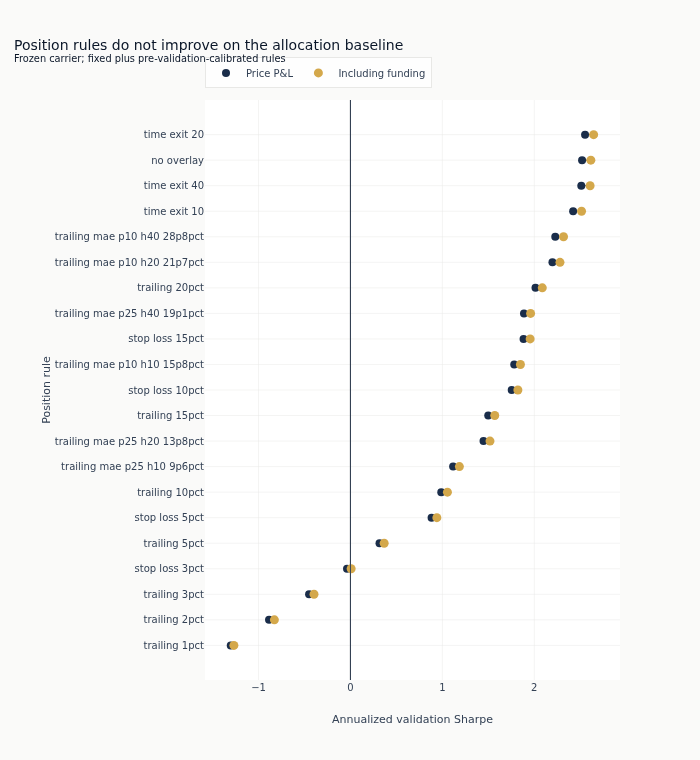

In [25]:
fig.add_trace(
    go.Scatter(
        x=ordered["price_only_sharpe"],
        y=labels,
        mode="markers",
        marker={"size": 8, "color": COLORS["slate"]},
        name="Price P&L",
    )
)
fig.add_trace(
    go.Scatter(
        x=ordered["with_funding_sharpe"],
        y=labels,
        mode="markers",
        marker={"size": 9, "color": COLORS["amber"]},
        name="Including funding",
    )
)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title={
        "text": "Position rules do not improve on the allocation baseline"
        "<br><sup>Frozen carrier; fixed plus pre-validation-calibrated rules</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Annualized validation Sharpe",
    yaxis_title="Position rule",
    height=760,
    margin={"l": 205},
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "x": 0},
)
fig.show()

No overlay remains the validation leader after correction. It reaches +2.741 price-only and
+2.849 including funding, compared with +2.689 and +2.797 for the 20-bar time exit. The time exit
gives up about 0.052 Sharpe while funding-inclusive maximum drawdown is nearly unchanged at 21.6%
versus 21.4%. The position rules do not improve this historical carrier.

## Drawdown is a trade-off, not a second ranking target

A rule that reduces drawdown by destroying the return source is not an improvement. The frontier
below uses the same funding-inclusive daily equity for both axes. Labels identify the baseline and
representative 20-bar time exit; the other rules remain available through hover.

In [26]:
color_map = {
    "baseline": COLORS["neutral"],
    "time_exit": COLORS["amber"],
    "trailing_stop": COLORS["blue"],
    "stop_loss": COLORS["slate"],
}

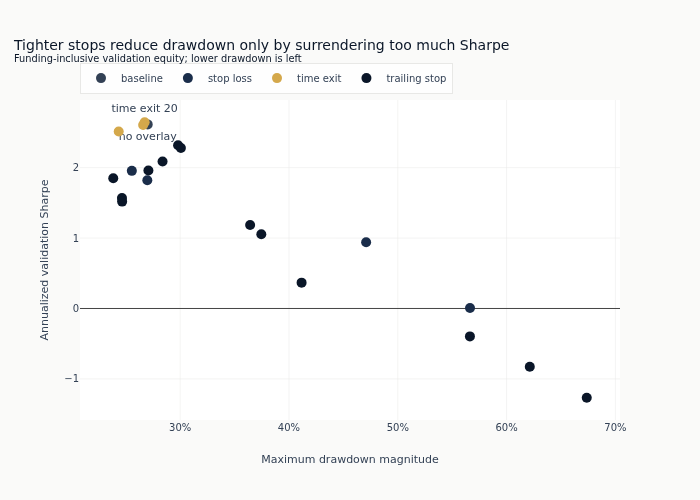

In [27]:
fig = go.Figure()
for risk_type in replay["risk_type"].unique().sort().to_list():
    subset = replay.filter(pl.col("risk_type") == risk_type)
    text = [
        row["risk_name"].replace("_", " ")
        if row["risk_name"] in {"no_overlay", "time_exit_20"}
        else ""
        for row in subset.iter_rows(named=True)
    ]
    positions = [
        "bottom center" if row["risk_name"] == "no_overlay" else "top center"
        for row in subset.iter_rows(named=True)
    ]
    fig.add_trace(
        go.Scatter(
            x=-subset["with_funding_max_drawdown"],
            y=subset["with_funding_sharpe"],
            mode="markers+text",
            text=text,
            textposition=positions,
            marker={"size": 10, "color": color_map[risk_type]},
            name=risk_type.replace("_", " "),
            customdata=subset["risk_name"],
            hovertemplate=("%{customdata}<br>drawdown=%{x:.1%}<br>Sharpe=%{y:.2f}<extra></extra>"),
        )
    )
fig.update_layout(
    title={
        "text": "Tighter stops reduce drawdown only by surrendering too much Sharpe"
        "<br><sup>Funding-inclusive validation equity; lower drawdown is left</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Maximum drawdown magnitude",
    xaxis_tickformat=".0%",
    yaxis_title="Annualized validation Sharpe",
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "x": 0},
)
fig.show()

## Publication boundary

This replay is a corrected accounting view of frozen v3.0 history, not a current v3.1 carrier.
The current registry now contains a separate 24-hour backtest and cohort surface that selects its
own carrier and risk rule. The final strategy notebook reports that current result without merging
it with this historical replay.

## Key takeaways

1. The registered risk stage remains frozen v3.0 history; five validation-calibrated MAE rows are
   quarantined and all current replays use `register=False`.
2. Position-level rules operate on trade paths. They do not detect a change in the signal's
   economic regime.
3. Six MAE thresholds are learned only from the complete pre-validation price prefix; fixed rules
   retain their exact registered definitions.
4. The corrected comparison uses one return definition for Sharpe and drawdown, including every
   official funding settlement.
5. Requested top-5 is capped dynamically on 186 early timestamps, so the risk comparison is not
   contaminated by one-sided books.
6. Current v3.1 selects its risk overlay on a separate lineage, so this historical replay cannot
   substitute for the current carrier.
7. The final strategy notebook must synthesize only corrected results or clearly label frozen
   registry values as historical.